In [1]:
import os
os.environ['OMP_NUM_THREADS']      = '1'
os.environ['MKL_NUM_THREADS']      = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

In [47]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
sys.path.append('../..')
sys.path.append('../../results')

from sklearn.linear_model import Ridge
from utils import W_from_J, init_cond, solve_rk4_springBox
from fig2.fig2_functions import classify_all
from fig7.new_orbits_functions import (
    make_many_biases, find_fixed_points, jacobians_for_all_fixed_points,
    precompute_all_orbits, solve_rk4_bias_controlled
)
from fig7.readout_functions import (
    r2_score, plot_shape_fit,
    fit_assignment, run_all_permutations, print_top, plot_rank,
    build_weighted_training_set_noisy, augment_training_with_noisy_fixed_points
)
from fig7.fig7_functions import (
    ensure_TN, segments_from_transition_times,
    plot_segments_cycles_separately, plot_bias_over_time
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# --- Load data ---
# Download from Zenodo [DOI] and place under data/fig2/
data_root = '../../data/fig2'

with open(f'{data_root}/sigma1/Ws.pkl', 'rb') as f:
    data2 = pickle.load(f)

solutions2  = [d for d in data2 if not np.all(d.get('W') == 0)]
matrices2   = [d['W'] for d in solutions2]
behaviours2 = np.load(f'{data_root}/behaviours/behaviours2.npy', allow_pickle=True).tolist()

classified         = classify_all(matrices2, [], [], behaviours2, [], [])
mat2_without_chaos = [matrices2[i] for i in classified[0]['idx_without_chaos']]

N    = 100
T    = 20
dt   = 0.005
tauE = 0.1
tauI = 0.1
a = np.ones(N); c = np.ones(N); b = np.zeros(N)

J = mat2_without_chaos[0]
W, _ = W_from_J(J, a, b, c)
initial_conditions = init_cond(J)

In [10]:
# --- Generate biased fixed points ---
from utils import f as _f

betas    = [-0.9, -0.7, 0.7, 0.7]
epsilons = [0.5,   0.2,  1.0, 0.3]
seeds    = [10,    19,   38,  7  ]

biases, etas = make_many_biases(N, betas, epsilons, seeds=seeds)
r0s = np.vstack([_f(biases[:, k], a, b, c) for k in range(biases.shape[1])]).T

r_stars, ok, info = find_fixed_points(W, biases, r0s, alpha=0.001, every=5000)
print('ok:', ok, 'iters:', info['iters'], '||F||:', info['residual'])

Js, ds, zs = jacobians_for_all_fixed_points(W, biases, r_stars)
max_real = np.array([np.max(np.linalg.eigvals(Js[:,:,i]).real)
                     for i in range(Js.shape[2])])
print('max Re(eig):', max_real)

# Prepend baseline (no-bias) Jacobian and zero fixed point
Js      = np.dstack((J, Js))
r_stars = np.column_stack((np.zeros(N), r_stars))
biases  = np.column_stack((np.zeros(N), biases))

k=0/4  ok=True  iters=112952  resid=9.991e-11
ok: [ True  True  True  True] iters: [112952 209402 111692  86990] ||F||: [9.99122679e-11 9.99586769e-11 9.99847665e-11 9.99554850e-11]
max Re(eig): [0.79970735 0.88983333 0.80313987 0.7201956 ]


In [14]:
# Directions only (no r_star added)
v0 = init_cond(Js[:,:,0])[:,4]
v1 = init_cond(Js[:,:,1])[:,4]
v2 = init_cond(Js[:,:,2])[:,1]
v3 = init_cond(Js[:,:,3])[:,0]
v4 = init_cond(Js[:,:,4])[:,0]

kick_dirs = np.column_stack([v0, v1, v2, v3, v4])

ico0 = (v0 + r_stars[:,0])
ico1 = v1 + r_stars[:,1]
ico2 = v2 + r_stars[:,2]
ico3 = v3 + r_stars[:,3]
ico4 = v4 + r_stars[:,4]
ic_orbits = np.column_stack([ico0, ico1, ico2, ico3, ico4])

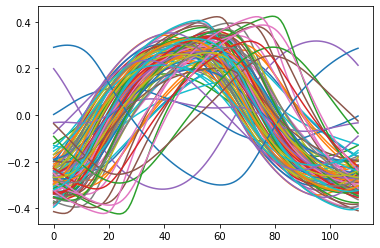

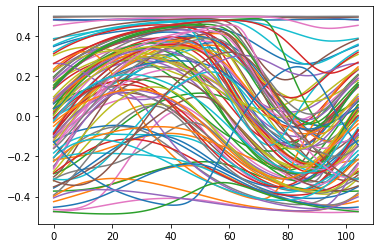

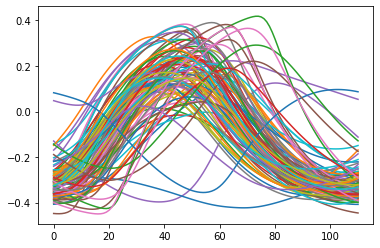

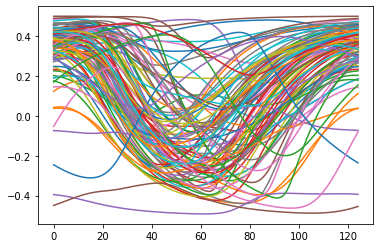

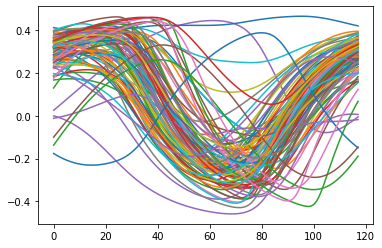

In [15]:
# --- Precompute orbit_infos for all 5 bias conditions ---
orbit_infos = precompute_all_orbits(
    ic_orbits, W, tauE, tauI, T, dt, a, b, c,
    r_stars, biases, no_freqs=3, wash=10)

In [19]:
# ---------------------------------------------------------------------
# Build your specific sequence schedule
# ---------------------------------------------------------------------
def build_sequence_FP0_O0_O1_FP1_O2_FP3_O3_O4_schedule(times, dur):
    """
    Your desired sequence:
      FP0 -> O0 -> O1 -> FP1 -> O2 -> FP3 -> O3 -> O4

    Required times keys (seconds):
      t_FP0_to_O0
      t_O0_to_O1
      t_O1_to_FP1
      t_FP1_to_O2
      t_O2_to_FP3
      t_FP3_to_O3   (this is your kick at t=20 in your example)
      t_O3_to_O4

    dur:
      dur['resume']   (seconds)
      dur['pull_fp']  (seconds)

    Returns a list of event dicts.
    """
    schedule = []

    # Start in FP0 at t=0 under bias 0 (we'll set initial bias index separately too)
    schedule.append(dict(kind="set_bias", t=0.0, k=0))

    # FP0 -> O0 : kick under bias 0
    #schedule.append(dict(kind="kick_orbit", t=times["t_FP0_to_O0"], k=0))
    schedule.append(dict(kind="resume_orbit", t0=times["t_FP0_to_O0"], t1=times["t_FP0_to_O0"]+ dur["resume"], k=0))

    # O0 -> O1 : switch to bias 1, resume to orbit 1
    schedule.append(dict(kind="set_bias", t=times["t_O0_to_O1"], k=1))
    schedule.append(dict(kind="resume_orbit", t0=times["t_O0_to_O1"], t1=times["t_O0_to_O1"] + dur["resume"], k=1))

    # O1 -> FP1 : pull to FP1 under bias 1
    schedule.append(dict(kind="pull_fp", t0=times["t_O1_to_FP1"], t1=times["t_O1_to_FP1"] + dur["pull_fp"], k=1))

    # FP1 -> O2 : switch to bias 2, resume to orbit 2
    schedule.append(dict(kind="set_bias", t=times["t_FP1_to_O2"], k=2))
    schedule.append(dict(kind="resume_orbit", t0=times["t_FP1_to_O2"], t1=times["t_FP1_to_O2"] + dur["resume"], k=2))

    # O2 -> FP4 : switch to bias 4, pull to FP4
    schedule.append(dict(kind="set_bias", t=times["t_O2_to_FP4"], k=4))
    schedule.append(dict(kind="pull_fp", t0=times["t_O2_to_FP4"], t1=times["t_O2_to_FP4"] + dur["pull_fp"], k=4))

    # FP4 -> O4 : switch to bias 4, resume to orbit 4
    #schedule.append(dict(kind="kick_orbit", t=times["t_FP3_to_O3"], k=3))
    #schedule.append(dict(kind="kick_orbit", t=times["t_FP3_to_O3"], k=3, dur=0.05))  # 100 ms
    schedule.append(dict(kind="set_bias", t=times["t_FP4_to_O4"], k=4))
    schedule.append(dict(kind="resume_orbit", t0=times["t_FP4_to_O4"], t1=times["t_FP4_to_O4"] + dur["resume"], k=4))

    # O4 -> O3 : switch to bias 3, resume to orbit 3
    schedule.append(dict(kind="set_bias", t=times["t_O4_to_O3"], k=3))
    schedule.append(dict(kind="resume_orbit", t0=times["t_O4_to_O3"], t1=times["t_O4_to_O3"] + dur["resume"], k=3))
    
    # O3 -> FP0: switch to bias 0, pull to FP0 
    schedule.append(dict(kind="set_bias", t=times["t_O3_to_FP0"], k=0))
    schedule.append(dict(kind="pull_fp", t0=times["t_O3_to_FP0"], t1=times["t_O3_to_FP0"] + dur["pull_fp"], k=0))

    
    # sort by time for safety
    def event_time(ev):
        return ev.get("t", ev.get("t0", 0.0))
    schedule = sorted(schedule, key=event_time)
    return schedule

# --- Build schedule and run controlled simulation ---
times = dict(
  t_FP0_to_O0 = 1.0,
  t_O0_to_O1  = 3.0,
  t_O1_to_FP1 = 5.0,
  t_FP1_to_O2 = 6.5,
  t_O2_to_FP4 = 8.5,
  t_FP4_to_O4 = 10.0, 
  t_O4_to_O3  = 12.0,
  t_O3_to_FP0  = 14.0
)
dur = dict(resume=0.2, pull_fp=0.2)

schedule = build_sequence_FP0_O0_O1_FP1_O2_FP3_O3_O4_schedule(times, dur)

#Run one long controlled sim. Start exactly at FP0 at t=0.
T_long = 15
t, r = solve_rk4_bias_controlled(
    W=W, a=a, b=b, c=c,
    tauE=tauE, tauI=tauI,
    T=T_long, dt=dt,
    biases=biases,
    r_stars=r_stars,
    kick_dirs=kick_dirs,
    orbit_infos=orbit_infos,
    schedule=schedule,
    kick_gain=1,
    K_fp=200.0,
    resume_gain=100.0,
    k_norm=0.6, k_tan=0.15,
    sigma_ou=0.004242, # 0.004242 
    tau_c=0.01, t_start_noise=0, rng=np.random.default_rng(13),
    k0=0,
    x0=r_stars[:,0])


In [34]:
# --- Shape specs and cache ---
# Edit paths to point to your shapes/ folder
SHAPE_SPECS = {
    'heart':      dict(path='./shapes/heart3.png',     scale=1, angle=0.0, smooth_iter=10),
    'circle':    dict(path='./shapes/circle.jpg',     scale=1, angle=0.0, smooth_iter=10),
    'hat':       dict(path='./shapes/hat.png',        scale=1, angle=0.0, smooth_iter=10),
    'butterfly': dict(path='./shapes/butterfly3.jpg', scale=1, angle=0.0, smooth_iter=10),
    'rose':      dict(path='./shapes/rose.jpg',       scale=1, angle=0.0, smooth_iter=10),
}
shape_names = list(SHAPE_SPECS.keys())
orbit_ks    = [0, 1, 2, 3, 4]
_shape_cache = {}

In [35]:
# --- Find best shape assignment ---
results = run_all_permutations(orbit_infos, orbit_ks, shape_names,
                               _shape_cache, SHAPE_SPECS)
print_top(results, orbit_ks, top=10)
best_assignment = results[0]['assignment']
print('Best:', best_assignment)

  1) R2=0.999511   k0:circle | k1:butterfly | k2:heart | k3:rose | k4:hat
  2) R2=0.999487   k0:circle | k1:butterfly | k2:heart | k3:hat | k4:rose
  3) R2=0.999484   k0:circle | k1:hat | k2:heart | k3:butterfly | k4:rose
  4) R2=0.999473   k0:circle | k1:rose | k2:heart | k3:butterfly | k4:hat
  5) R2=0.999405   k0:circle | k1:butterfly | k2:hat | k3:rose | k4:heart
  6) R2=0.999356   k0:circle | k1:butterfly | k2:rose | k3:hat | k4:heart
  7) R2=0.999350   k0:circle | k1:butterfly | k2:hat | k3:heart | k4:rose
  8) R2=0.999347   k0:circle | k1:heart | k2:rose | k3:butterfly | k4:hat
  9) R2=0.999333   k0:circle | k1:hat | k2:heart | k3:rose | k4:butterfly
 10) R2=0.999330   k0:circle | k1:heart | k2:hat | k3:butterfly | k4:rose
Best: {0: 'circle', 1: 'butterfly', 2: 'heart', 3: 'rose', 4: 'hat'}


In [39]:
# --- Build training set ---


# Training data for orbits
X_orbits, Y_orbits, w_orbits, meta_orbits = build_weighted_training_set_noisy(
    orbit_infos=orbit_infos, best_assignment=best_assignment,
    W=W, a=a, b=b, c=c, tauE=tauE, tauI=tauI, dt=dt, biases=biases,
    shape_cache=_shape_cache, shape_specs=SHAPE_SPECS,
    orbit_ks=(0,1,2,3,4), n_noisy_per_orbit=20, seed0=0, burn_in=0,
    sigma_ou=0.003, tau_c=0.01, w_det=1.0, w_noisy=0.3
)
print("X_orbits:", X_orbits.shape, "Y_orbits:", Y_orbits.shape, "w_orbits:", w_orbits.shape)


# Choose targets
fp_targets = {
    0: np.array([0.0, 0]),     # baseline/rest
    1: np.array([0, 0.5]),    
    4: np.array([-0.2, -0.2]),
}

X_ofp, Y_ofp, w_ofp, meta_ofp = augment_training_with_noisy_fixed_points(
    X_orbits, Y_orbits, w_orbits,
    r_stars=r_stars, biases=biases, ks_fp=(0,1,4), fp_targets=fp_targets,
    W=W, a=a, b=b, c=c, tauE=tauE, tauI=tauI, dt=dt,
    T_fp=0.5, burn_in=0, sigma_ou=0.003, tau_c=0.01, n_rollouts=10, w_fp=0.2, stride=10
)

X_orbits: (11970, 100) Y_orbits: (11970, 2) w_orbits: (11970,)


In [40]:
# --- Fit readout model ---
model = Ridge(alpha=0.0, fit_intercept=True)
model.fit(X_ofp, Y_ofp, sample_weight=w_ofp)

with open('readout_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [42]:
# --- Apply model to long trajectory ---
X_long = ensure_TN(r, N=100)
Y_long = model.predict(X_long)

In [43]:
# --- Transition times and segmentation ---
transition_times_ordered = [
    times['t_FP0_to_O0'], times['t_O0_to_O1'],  times['t_O1_to_FP1'],
    times['t_FP1_to_O2'], times['t_O2_to_FP4'], times['t_FP4_to_O4'],
    times['t_O4_to_O3'],  times['t_O3_to_FP0'],
]
segment_labels = ['FP0','O0','O1','FP1','O2','FP4','O4','O3','FP0']
segs = segments_from_transition_times(transition_times_ordered, dt, len(r))

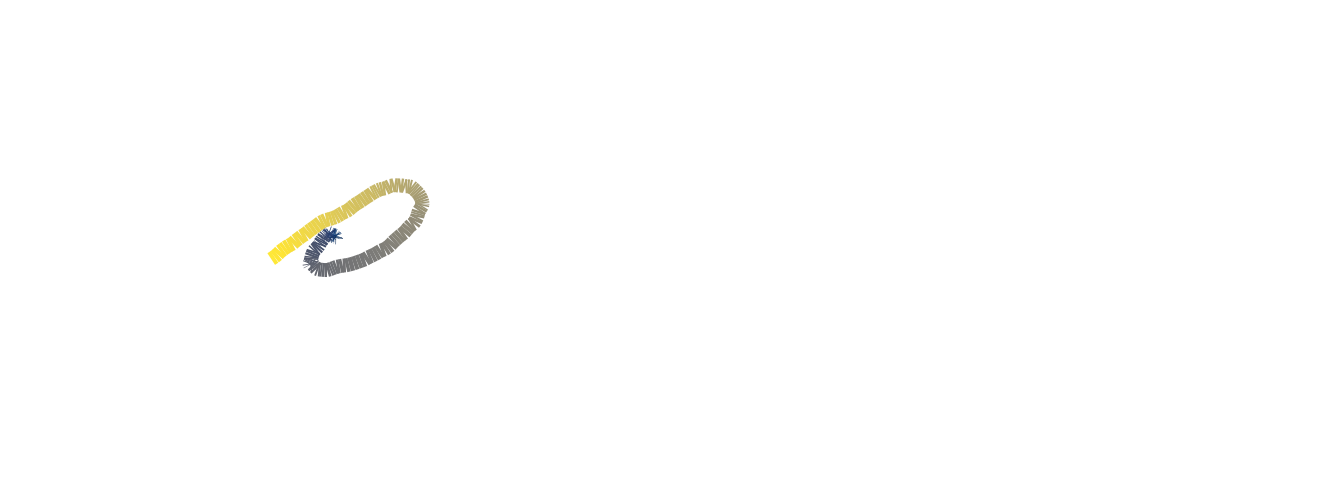

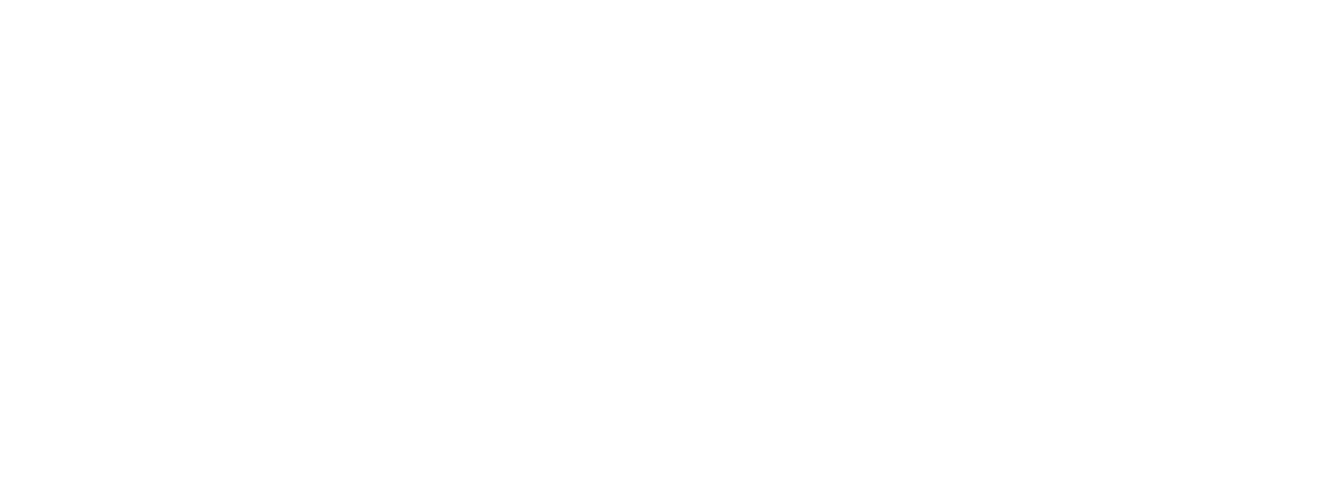

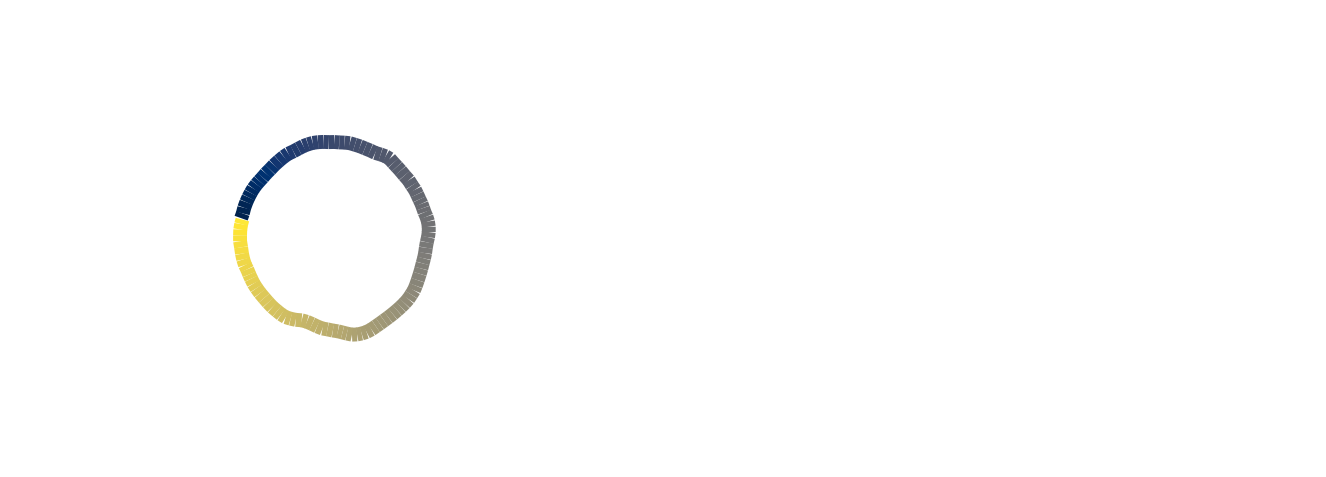

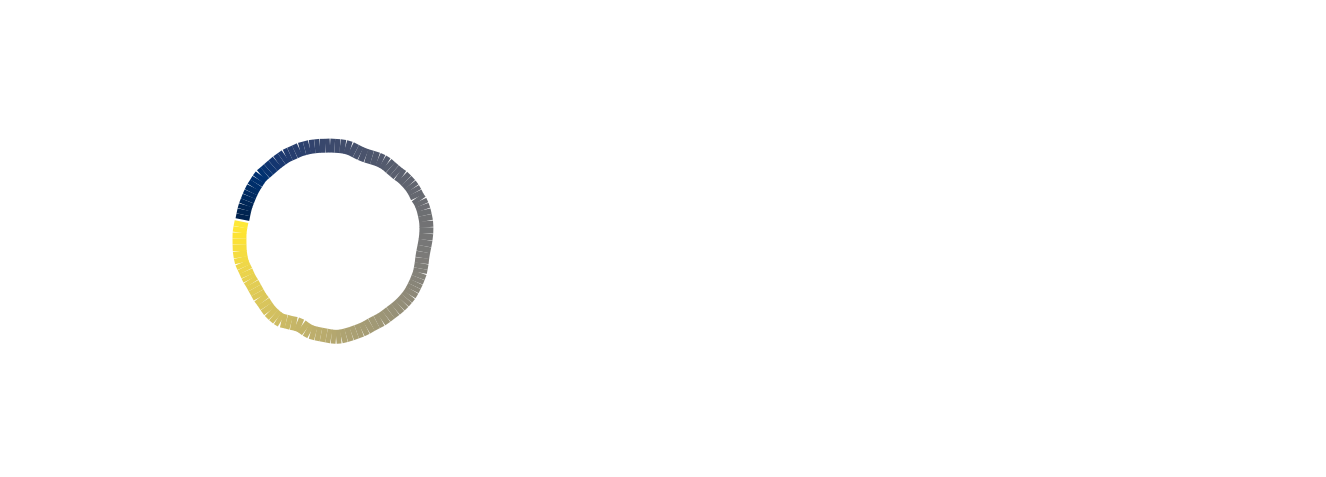

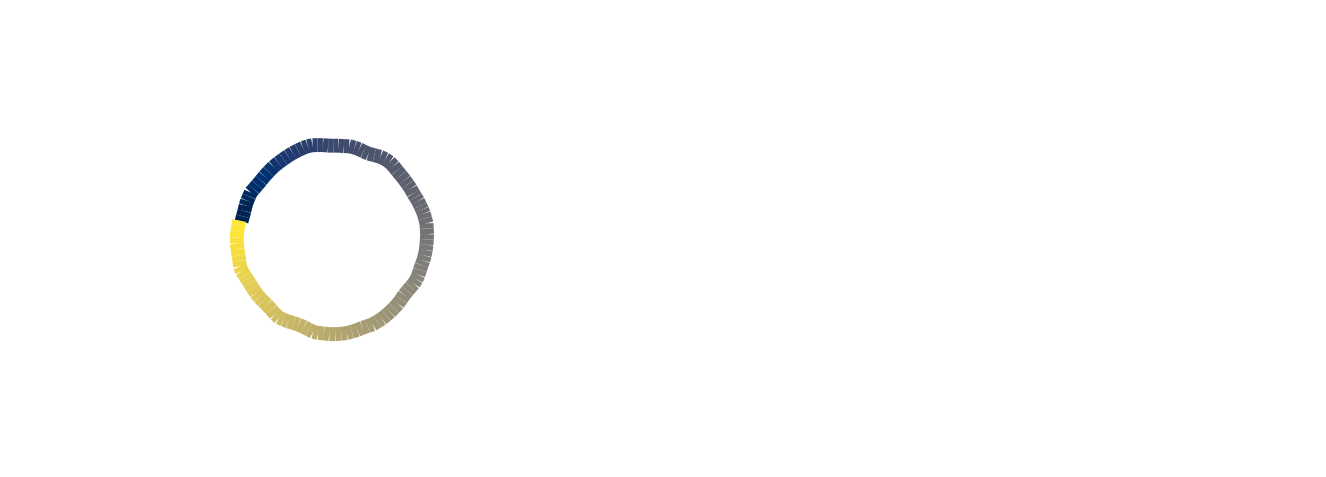

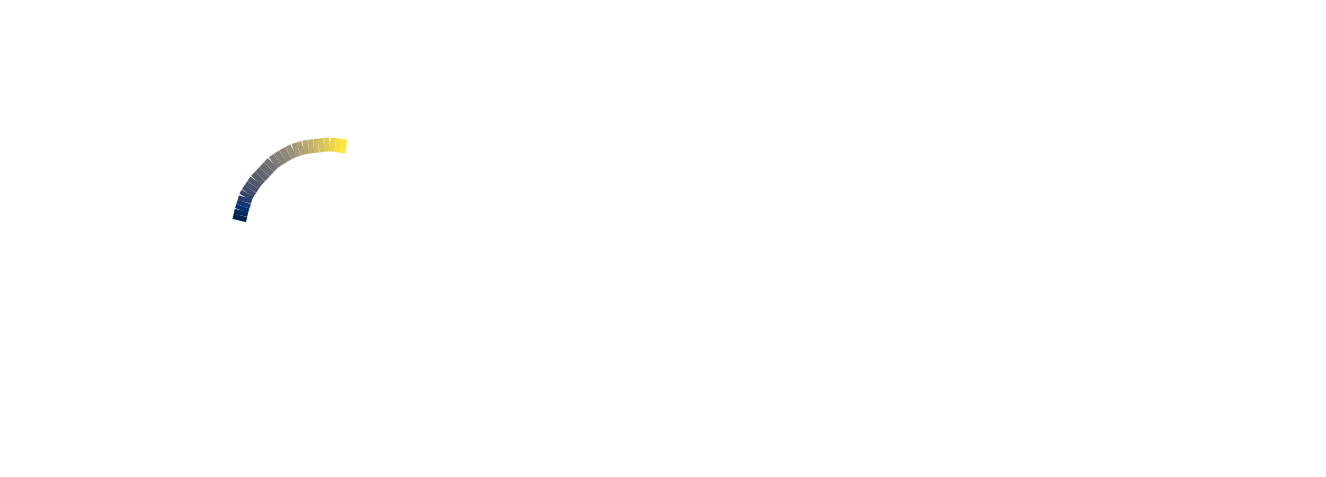

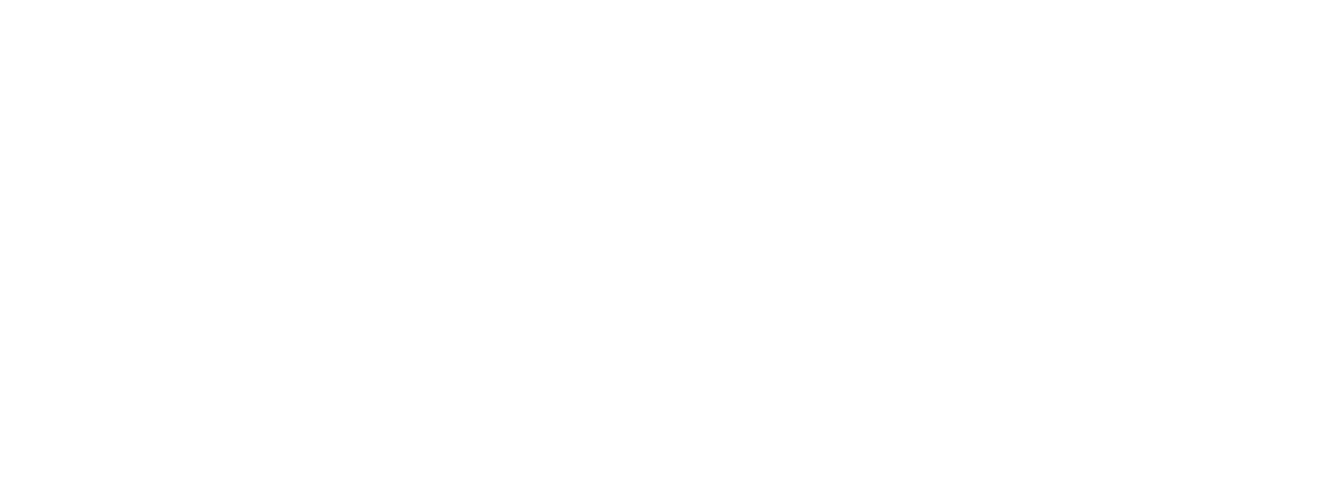

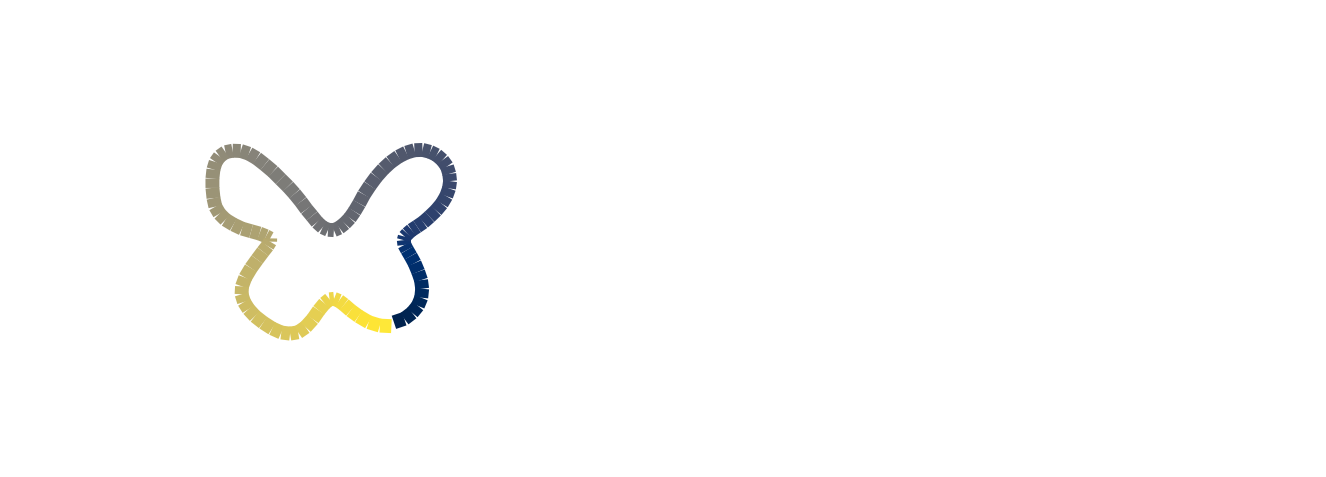

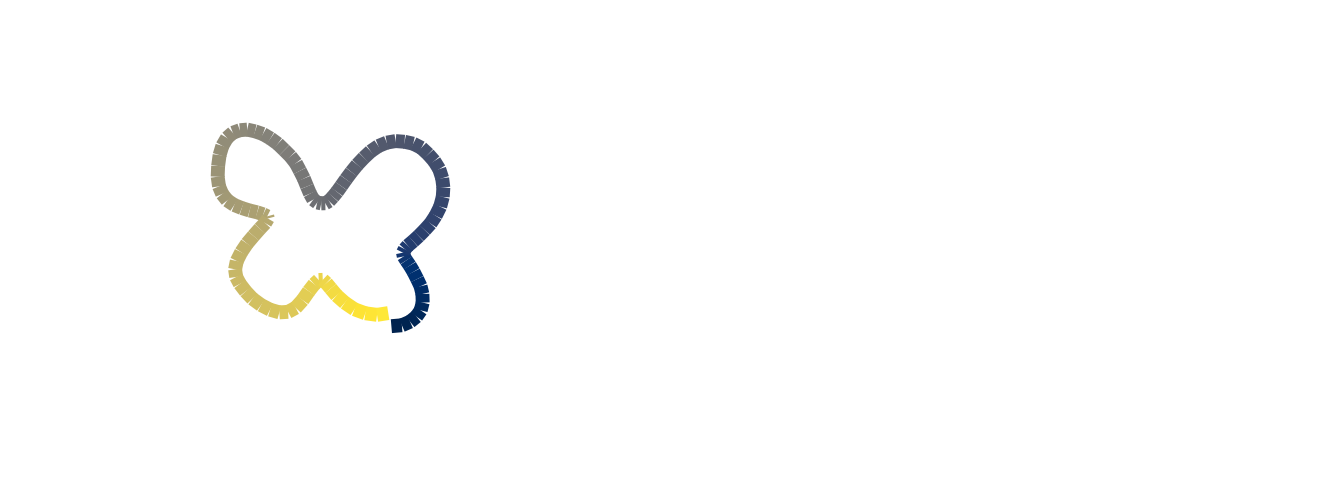

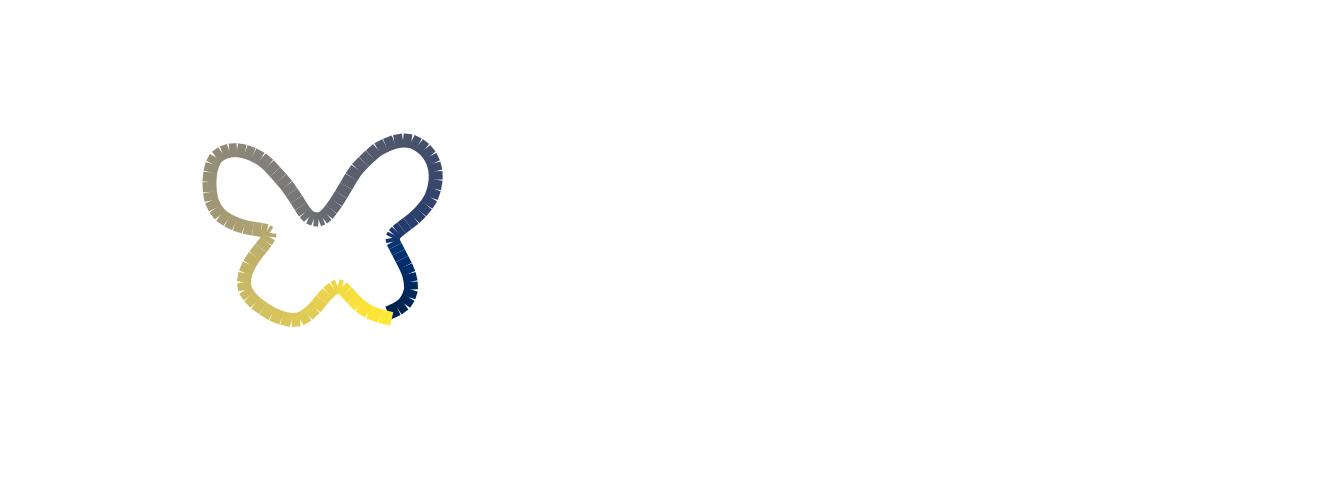

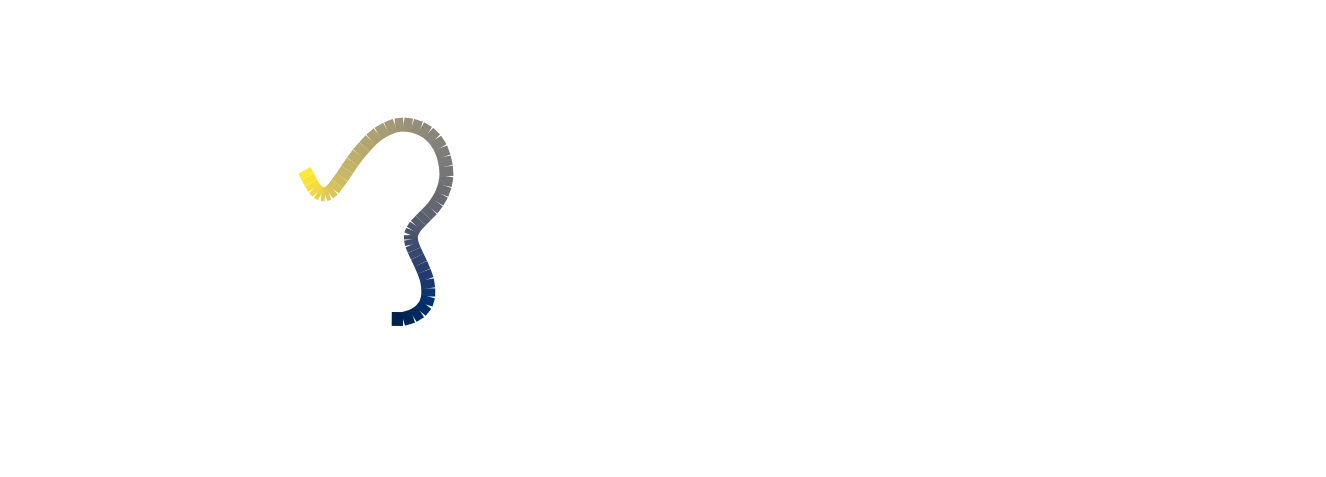

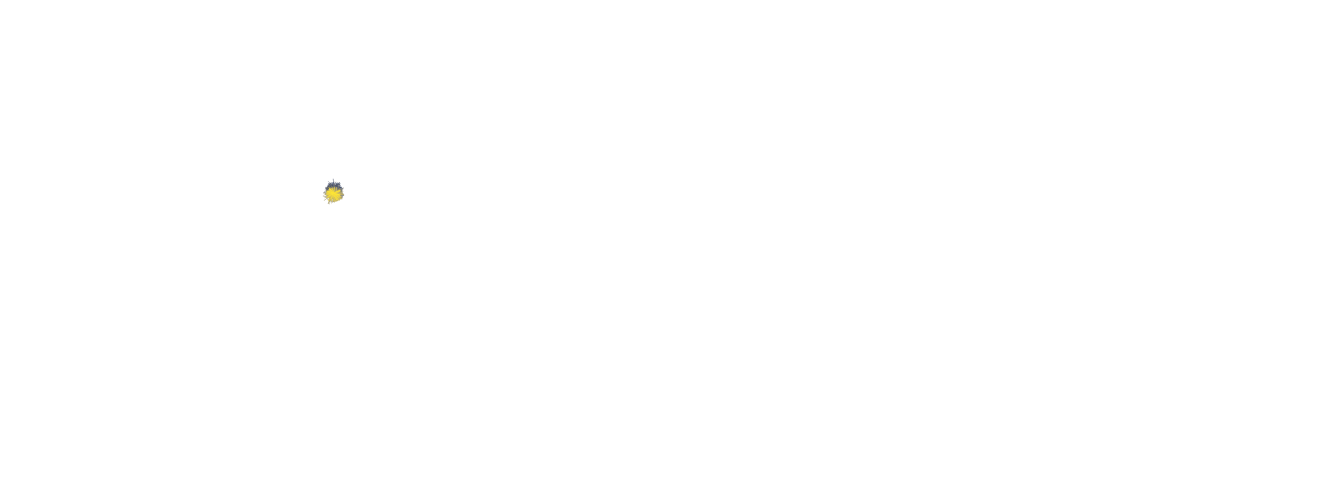

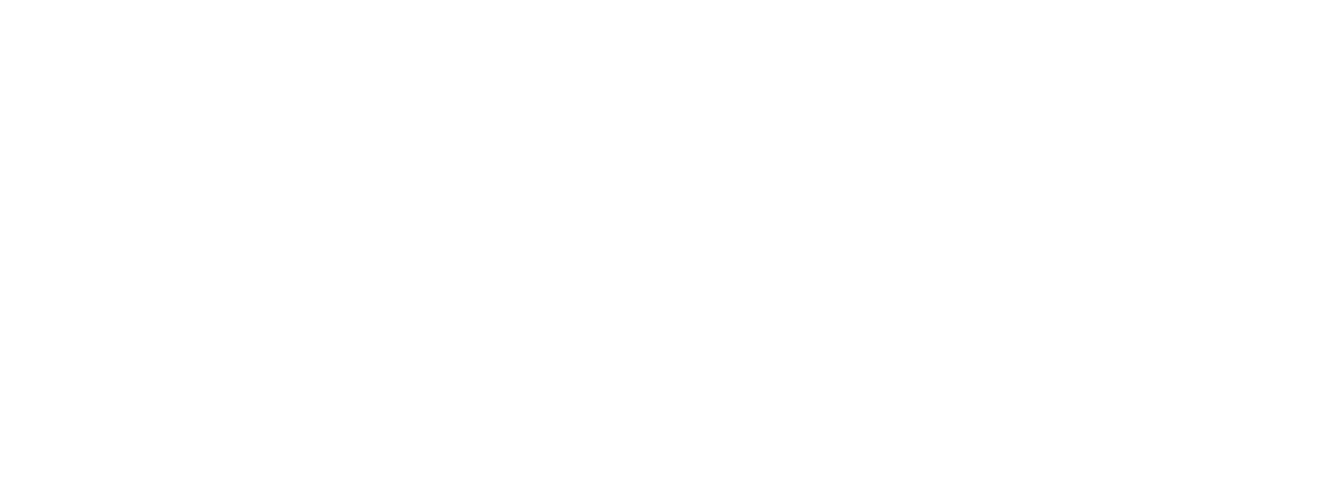

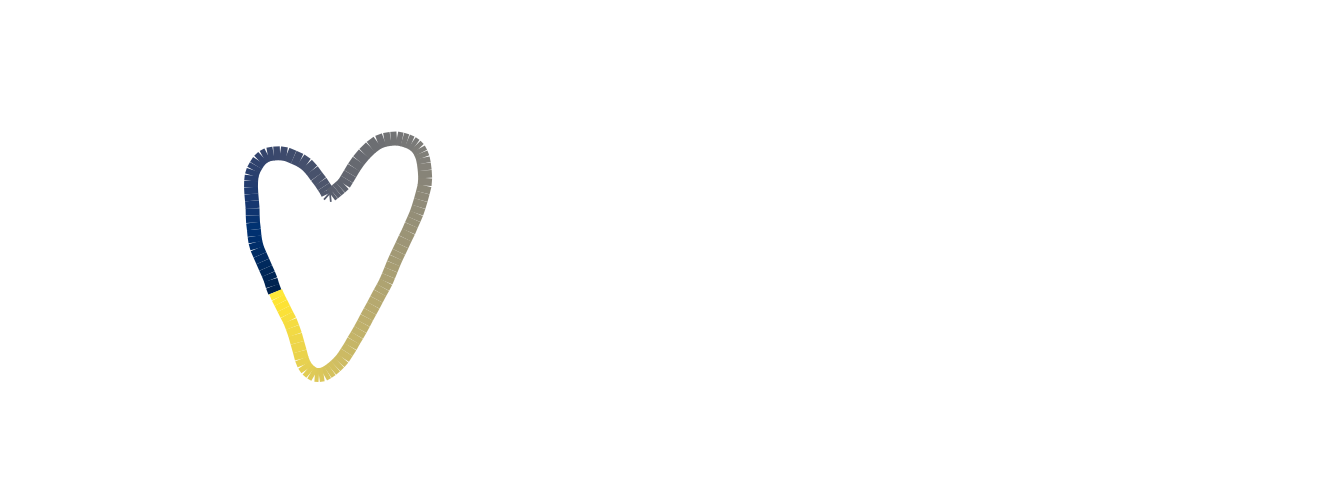

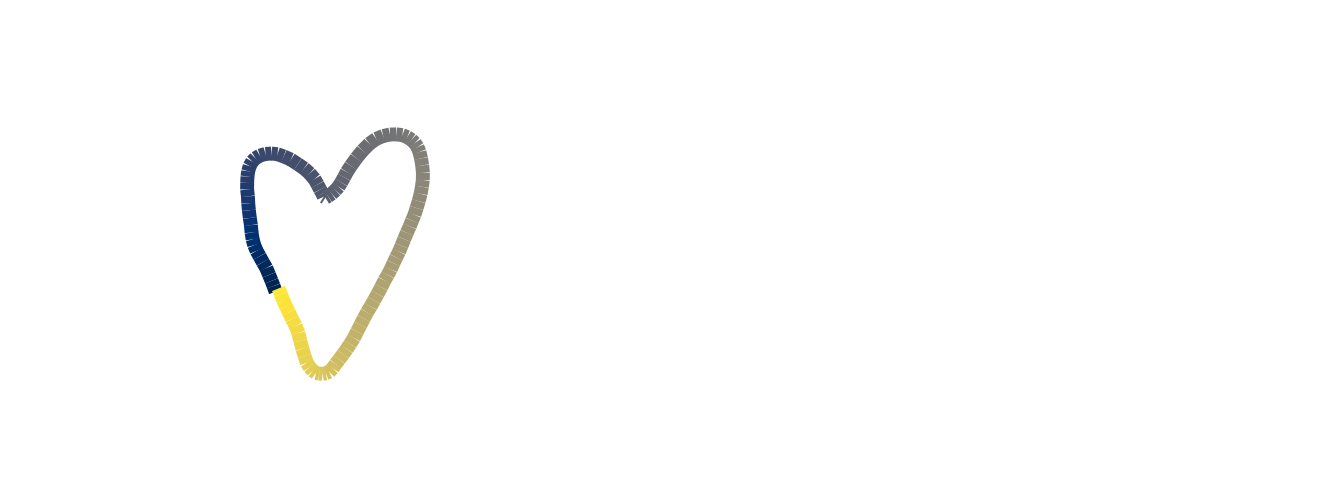

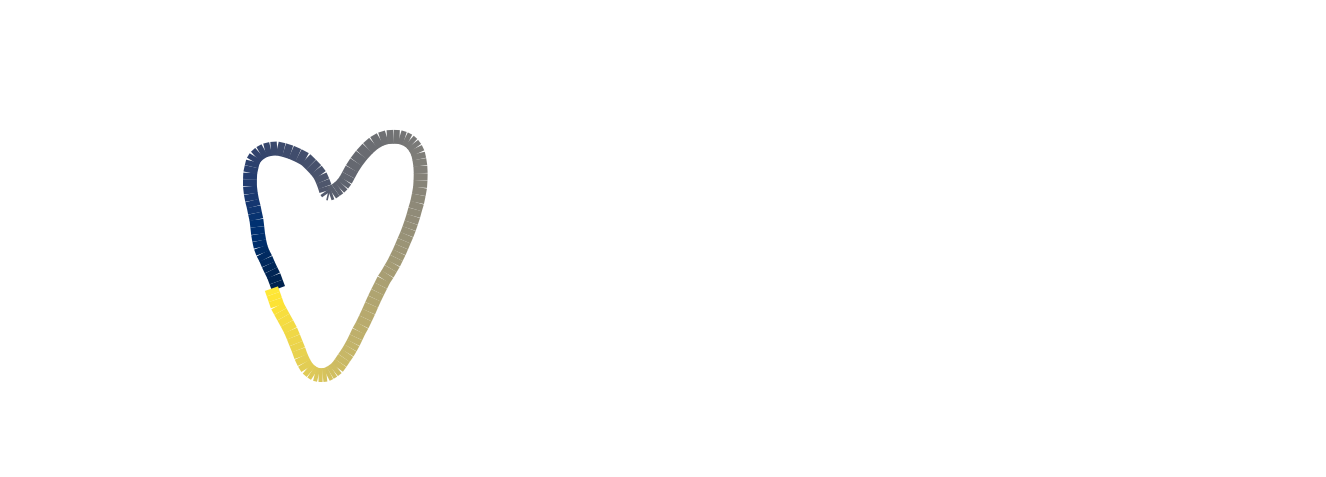

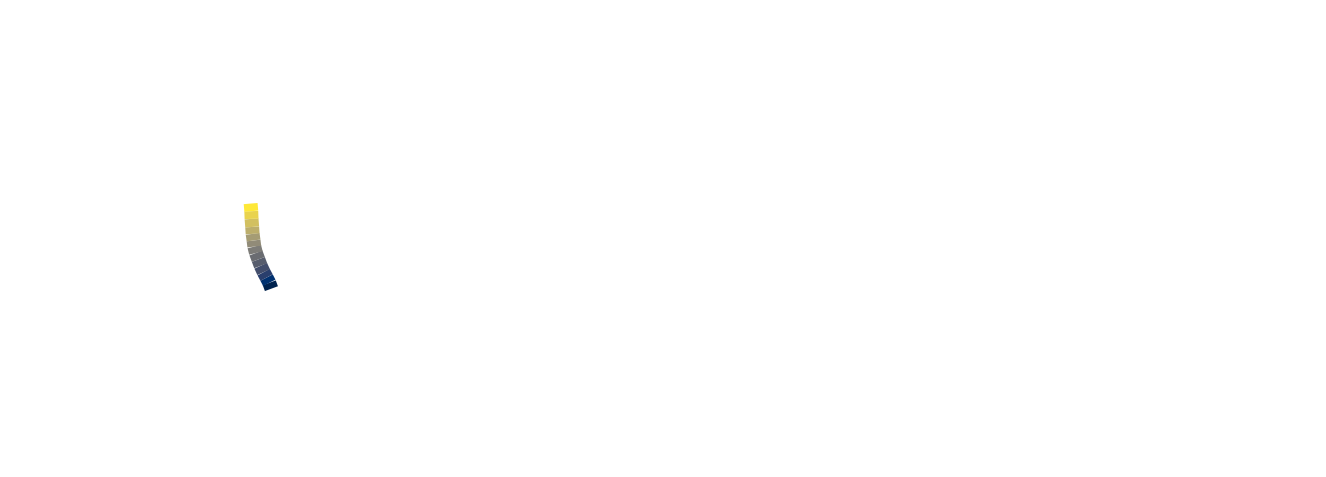

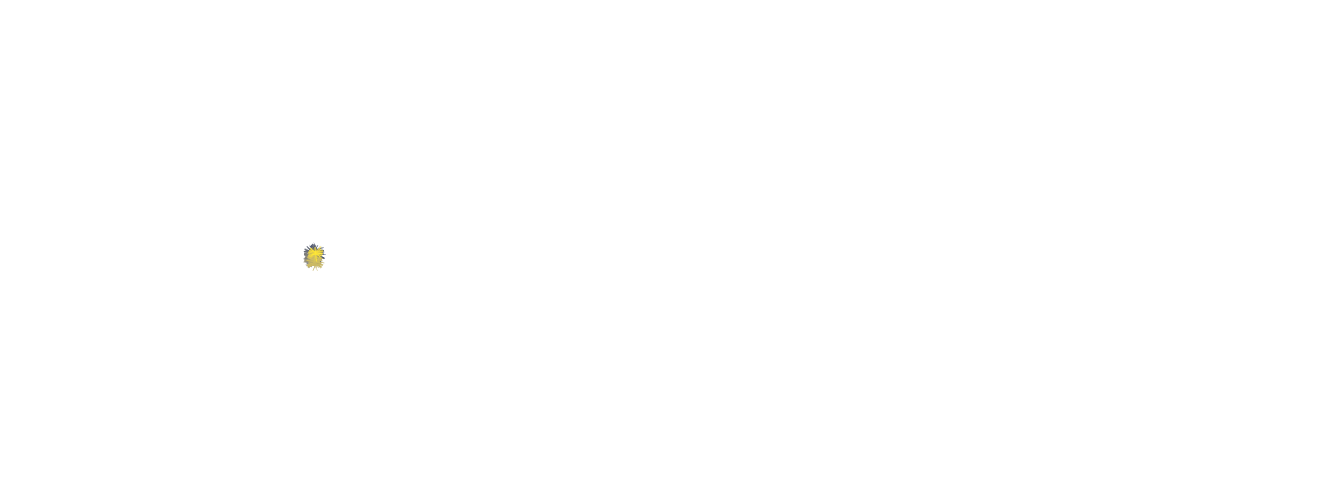

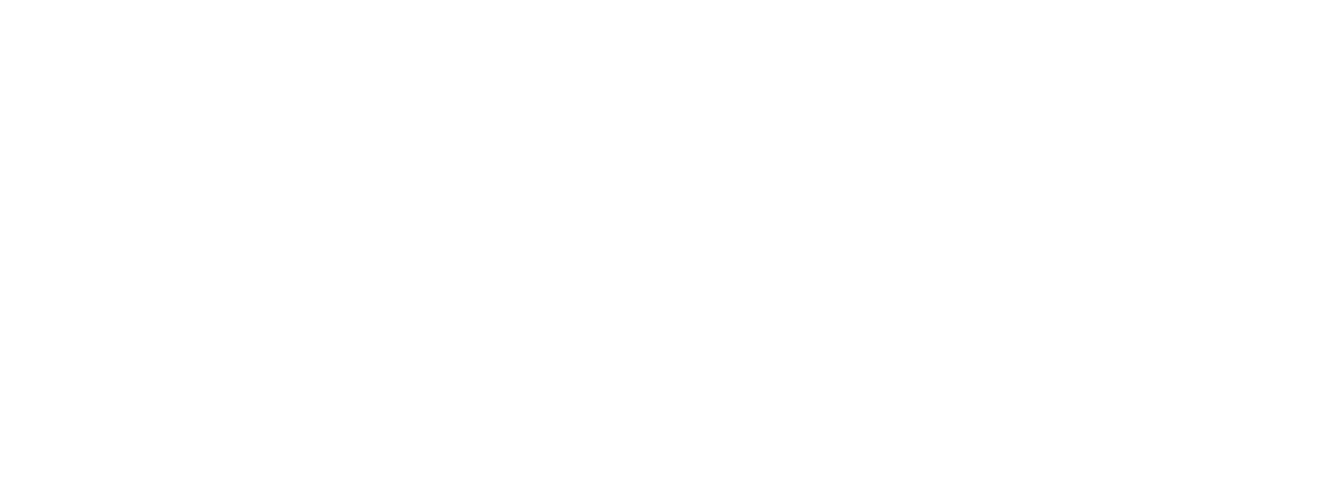

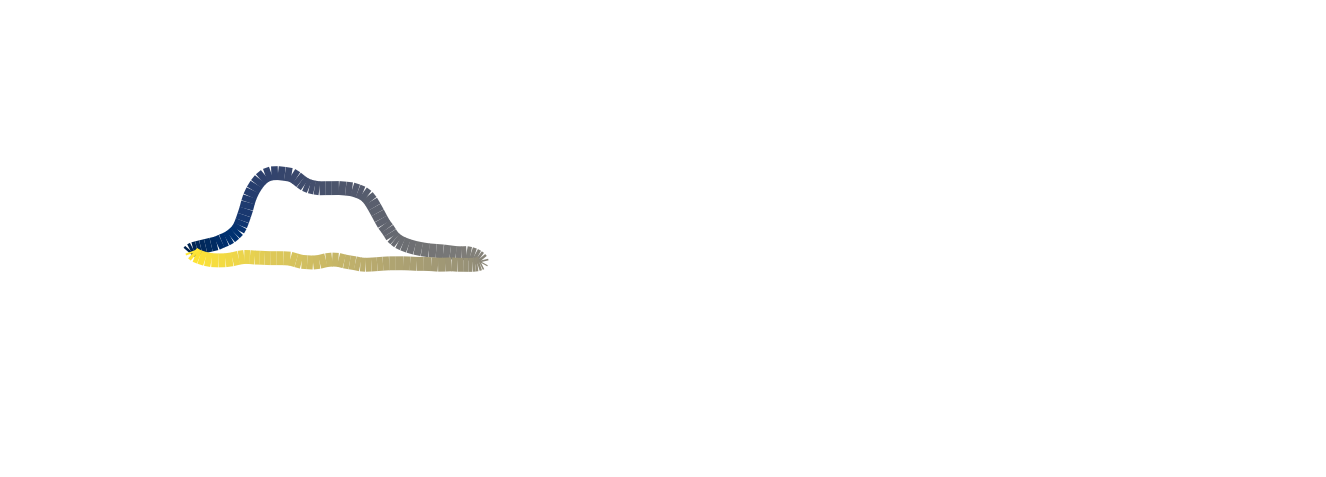

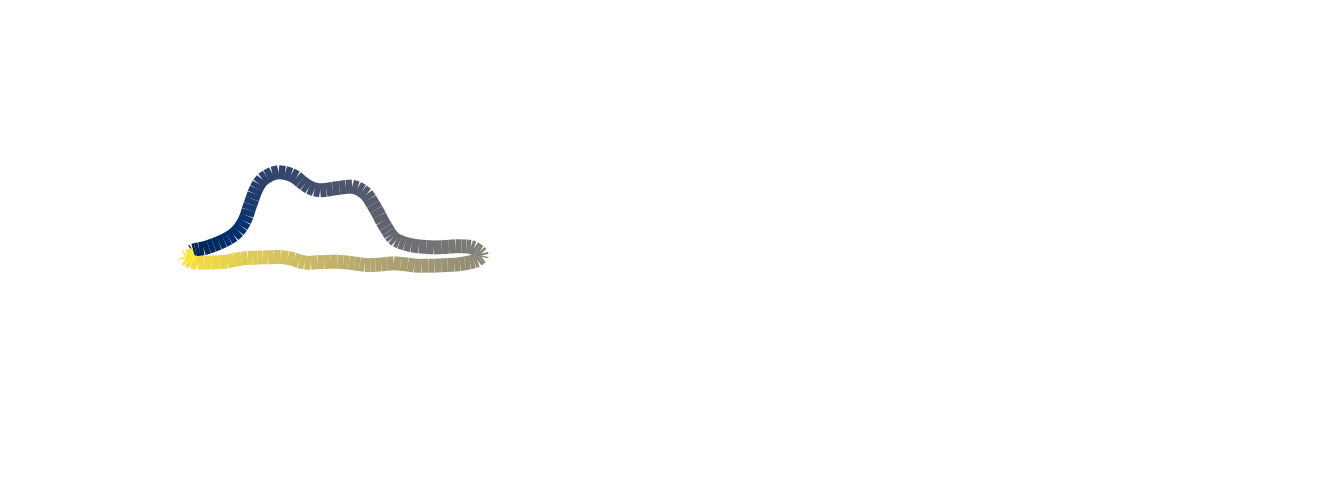

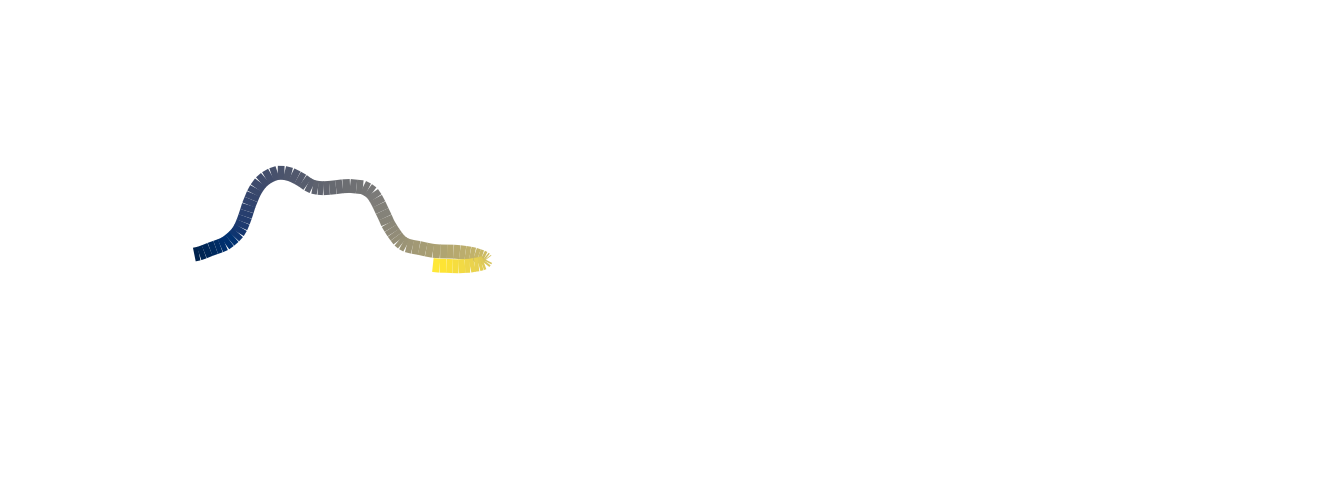

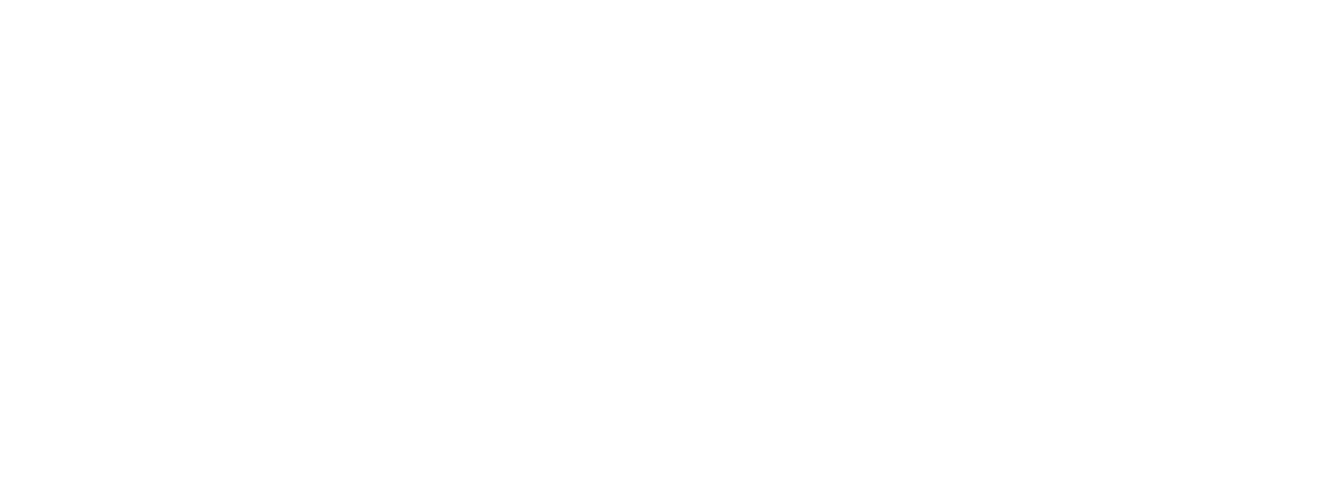

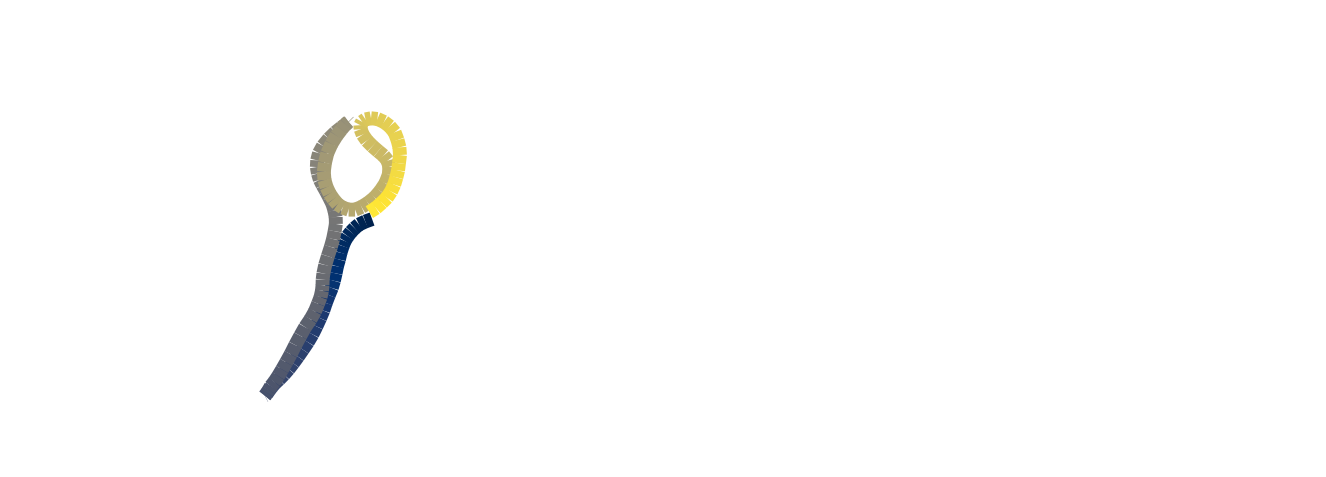

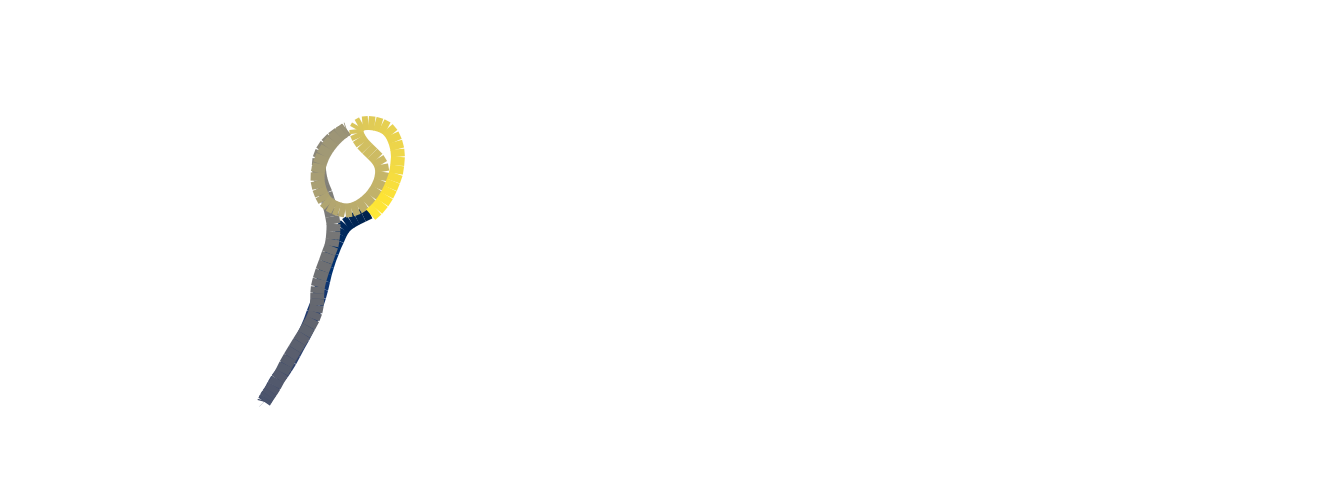

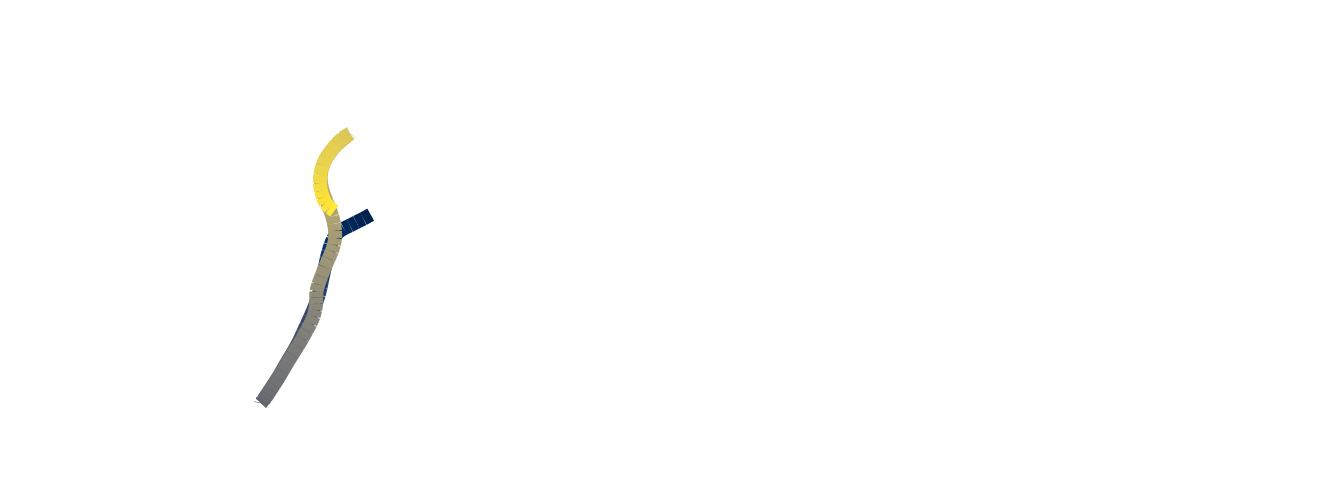

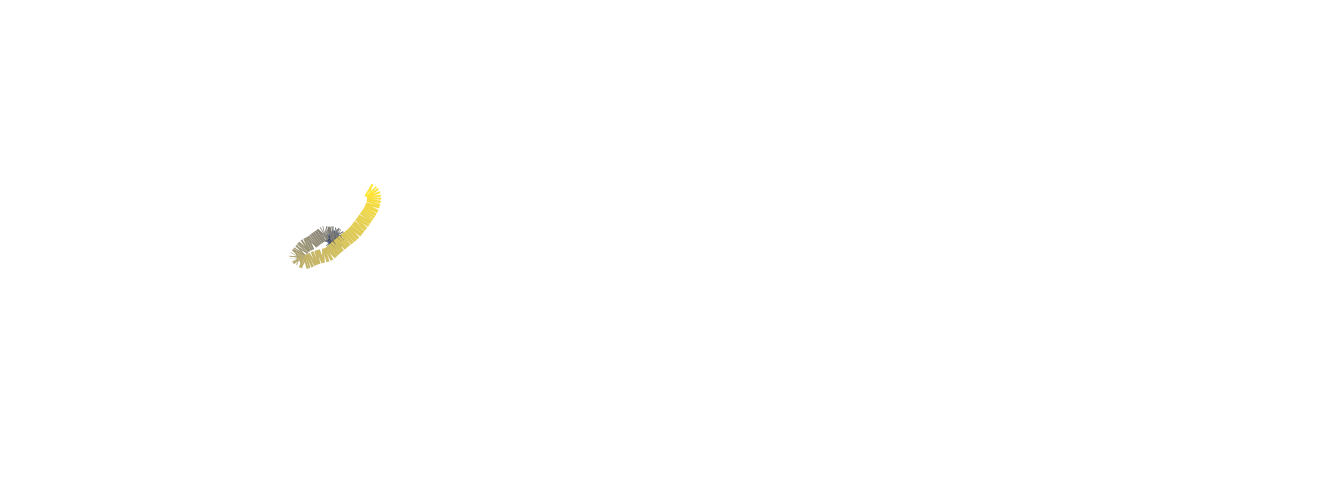

In [44]:
# --- Decoded shape plots per segment ---
orbit_transient_len = {'O0':40,'O1':40,'O2':50,'O3':60,'O4':80}
fp_transient_len    = {'FP0':25,'FP1':5,'FP4':28}

plot_segments_cycles_separately(
    Y_long=Y_long, segs=segs, segment_labels=segment_labels, dt=dt,
    orbit_transient_len=orbit_transient_len, fp_transient_len=fp_transient_len,
    cycle_period_samples=(105, 125), cycle_refine_window=50,
    cmap='cividis', show_transient_panel_for_orbits=True,
    lw=2, lw_transient=1, alpha_transient=0
)

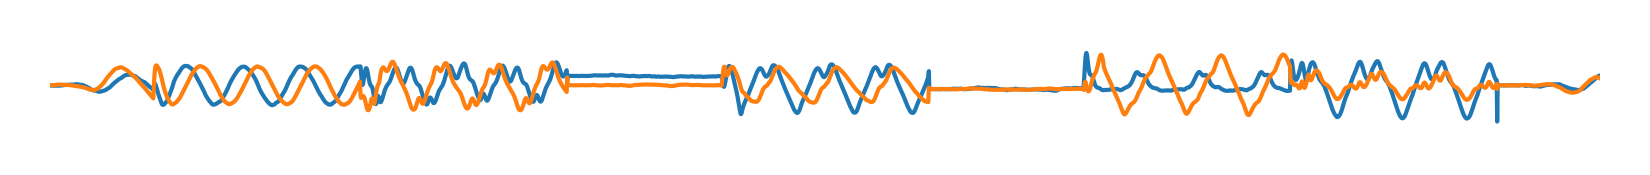

In [45]:
# --- Raw decoded output (2 readout dimensions) ---
fig, ax = plt.subplots(figsize=(4, 0.2), dpi=500)
ax.plot(t, Y_long[:,1], linewidth=0.6)
ax.plot(t, Y_long[:,0], linewidth=0.6)
ax.spines['top'].set_visible(False);    ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False); ax.spines['left'].set_visible(False)
for s in ax.spines.values(): s.set_linewidth(0.5)
ax.tick_params(width=0.5, pad=1, length=2, labelsize=5)
ax.set_xticks([]); ax.set_yticks([]); ax.set_xticklabels([])
ax.set_xlim(0, 15)
plt.show()

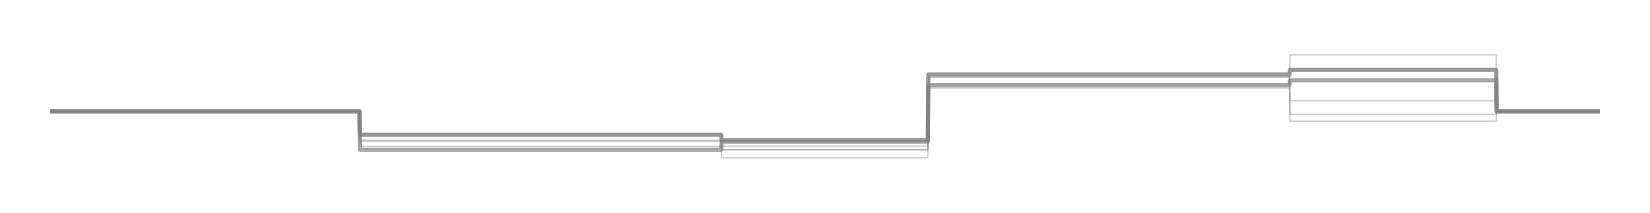

In [48]:
# --- Bias-over-time plot ---
segment_bias_ids = [0, 0, 1, 1, 2, 4, 4, 3, 0]
ax, B, bounds, idx_trans = plot_bias_over_time(
    biases=biases,
    transition_times_ordered=transition_times_ordered,
    dt=dt,
    T_total=len(r),
    segment_bias_ids=segment_bias_ids,
)
plt.show()